# CCO12: Relabel CCO10

In [27]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import ListedColormap
import anndata as ad
import seaborn as sns

In [4]:
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO12"
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO10"

In [3]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [5]:
adata_all = sc.read_h5ad(f"{PREV_DIR}/adata/cell_type_labelled/ALL.h5ad")

In [8]:
celltypes_dict = {
    '0': 'CM',
    '1': 'CM',
    '2': 'CM',
    '3': 'PR',
    '4': 'EC',
    '5': 'PR',
    '6': 'CM',
    '7': 'MP',
    '8': 'MP',
    '9': 'PR',
    '10': 'CM',
    '11': 'CM',
    '12': 'MP',
    '13': 'CF',
    '14': 'CM',
    '15': 'CM',
    '16': 'CM',
    '17': 'CM',
    '18': 'OT',
    '19': 'SM',
}

adata_all.obs['cell_type'] = adata_all.obs['leiden'].map(celltypes_dict)
adata_all.obs['cell_type'] = adata_all.obs['cell_type'].astype("category")

In [19]:
colormap = {
    "CM": (60/255, 170/255, 60/255),
    "EC": (230/255, 80/255, 160/255),
    "MP": (141/255, 160/255, 203/255),
    "PR": (255/255, 235/255, 125/255),
    "CF": (240/255, 180/255, 20/255),
    "SM": (220/255, 160/255, 30/255),
    "OT": (190/255, 190/255, 190/255),
    "OTH": (170/255, 170/255, 170/255),
}

samples = ['ALL', 'VO', 'HO', 'ReAgg-CM', 'Fus-HO', 'VasHO']
samples_old = ['ALL','VO','HO','CA','VHO','VCO']

cell_types = ['CM', 'PR', 'EC', 'MP', 'CF', 'SM', 'OT']

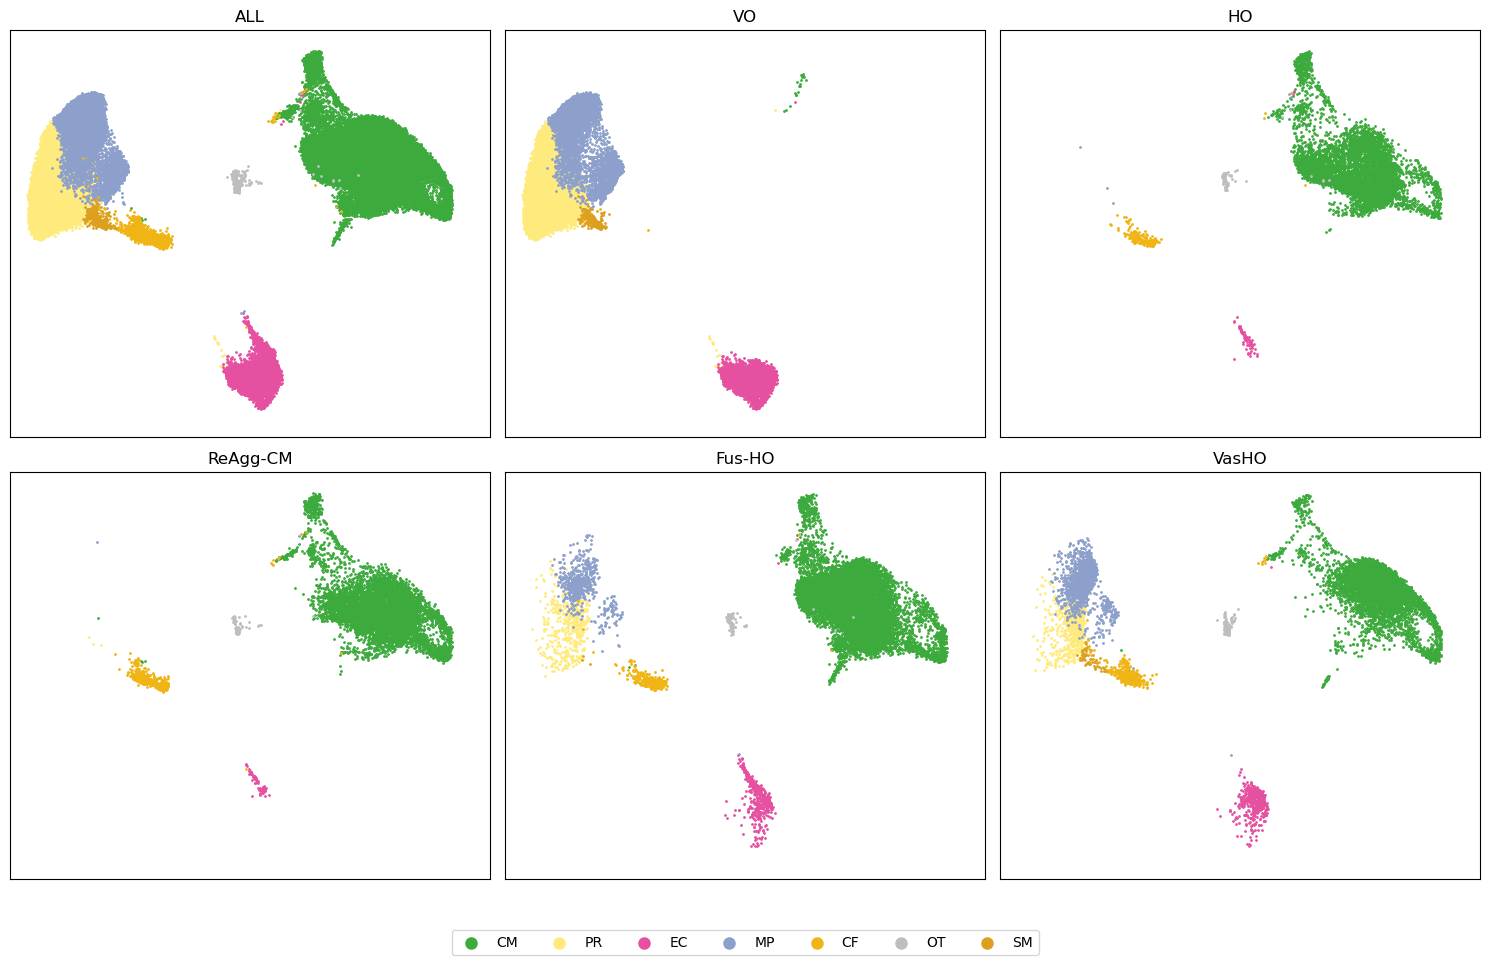

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for i, sample in enumerate(samples):
    if sample == "ALL":
        adata = adata_all
    else:
        adata = adata_all[adata_all.obs["batch"] == samples_old[i]]
    
    for j, ld in enumerate(adata_all.obs['cell_type'].unique()):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ld, 1], 
            label=ld, 
            color=colormap[ld], 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    axs[i].set_title(sample)
    axs[i].set_xlim([-11, 21])
    axs[i].set_ylim([-6, 18])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.075)
)

plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/UMAP/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

In [28]:
res = {"batch": [], "cell_type": [], "count": []}

for sample, sample_old in zip(samples, samples_old):
    if sample == "ALL":
        continue
    adata = adata_all[adata_all.obs["batch"] == sample_old]
    # res[sample] = []
    for ct in cell_types:
        res["batch"].append(sample)
        res["cell_type"].append(ct)
        res["count"].append((adata.obs["cell_type"] == ct).sum())

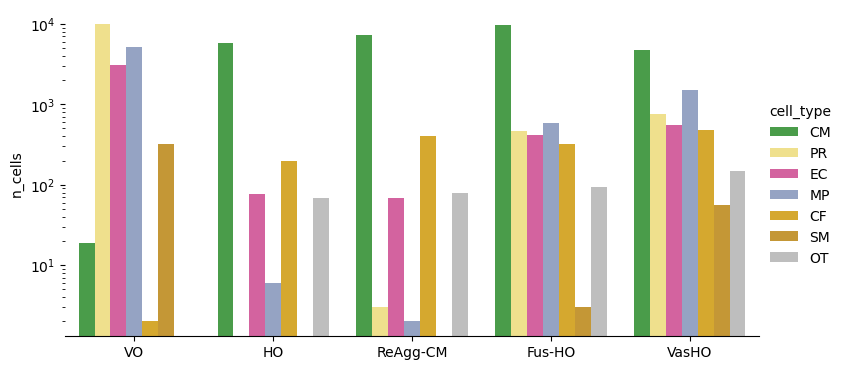

In [57]:
g = sns.catplot(
    data=pd.DataFrame(res), 
    kind="bar",
    x="batch", 
    y="count", 
    hue="cell_type",
    palette=colormap, 
    alpha=1.0, 
    height=4, aspect=2
)
g.despine(left=True)
for ax in g.axes.flat:
    ax.set_yscale("log")
g.set_axis_labels("", "n_cells")

plt.savefig(f"{WORK_DIR}/n_cell.batch.png")
plt.show()

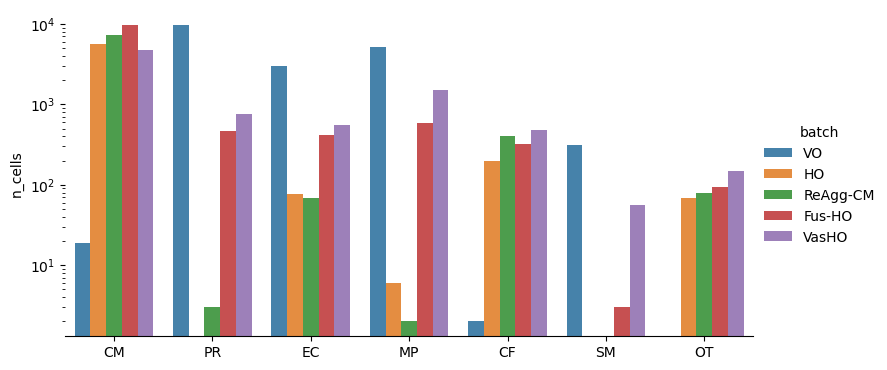

In [58]:
g = sns.catplot(
    data=pd.DataFrame(res), 
    kind="bar",
    x="cell_type", 
    y="count", 
    hue="batch",
    # palette=colormap, 
    alpha=.9, 
    height=4, aspect=2
)
g.despine(left=True)
for ax in g.axes.flat:
    ax.set_yscale("log")
g.set_axis_labels("", "n_cells")

plt.savefig(f"{WORK_DIR}/n_cell.celltype.png")
plt.show()

In [59]:
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=1, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

        if keygenes is not None and len(keygenes) > 0:
            df[df['gene'].isin(keygenes)].to_csv(f"{(save_tsv).strip('.tsv')}.marker.tsv", sep='\t')

In [70]:
volcano_plot2(adata_all[adata_all.obs["cell_type"] == "MP"], 
              "VO", 
              "VCO", 
              "MP.VO.VasHO", 
              label_type='batch', 
              keygenes=None, 
              save=f"{WORK_DIR}/MP.VO.VasHO.png", 
              save_tsv=f"{WORK_DIR}/MP.VO.VasHO.tsv",
              fc_thres=1, 
              pvalue_thres=5)